In [1]:
from astroquery.esa.xmm_newton import XMMNewton

In [4]:
XMMNewton.download_data(
    '0123701001',
    level='PPS',
    extension="FTZ,PNG,PDF",
    instname='PN',
    sourceno=f'0011',
    filename='data/test1'
)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from xmm_py_spec import plotting_settings
plotting_settings.set_mpl()

In [2]:
target_columns = [
 'src_num',
 'obs_id',
 'ons_start_date',
 'pn_ontime',
 'm1_ontime',
 'm2_ontime']


In [7]:
src_5359_df = pd.read_csv('../data/source_201237001010017_5359_results.csv')
src_5359_M1_df = pd.read_csv('../data/source_201237001010017_5359_individual_M1_results.csv')
# src_5359_clustered_df = pd.read_csv('../data/source_201237001010017_5359_clustered_results.csv')
# # src_5359_old_df = pd.read_csv('../data/source_201237001010017_5359_results_old.csv')
# src_1430_df = pd.read_csv('../data/source_201237001015028_1430_results.csv')
# src_7170_df = pd.read_csv('../data/source_201237001015035_7170_results.csv')

In [8]:
src_5359_df

,filename,date_obs,obs_id,mo2_model,mo2_cstat,mo2_dof,mo2_cstat_r,flux,flux_nerr,flux_perr,...,mo2_PhoIndex_step_2d,mo2_PhoIndex_step_2d_lower,mo2_PhoIndex_step_2d_upper,mo2_PhoIndex_step_2d_perr,mo2_PhoIndex_step_2d_nerr,mo2_nH_step_2d,mo2_nH_step_2d_lower,mo2_nH_step_2d_upper,mo2_nH_step_2d_perr,mo2_nH_step_2d_nerr
0,P0022740201PNS003SRSPEC001C.FTZ,2001-10-27 19:10:18,22740201,ph*zph*zpo,21.506674,20,1.075334,6.331529e-15,4.767614e-15,6.939431e-15,...,0.60,0.297118,1.597574,0.997574,0.302882,0.251189,0.100000,5.657655,5.406467,0.151189
1,P0022740301PNS003SRSPEC001C.FTZ,2001-11-04 06:58:27,22740301,ph*zph*zpo,2.409823,4,0.602456,5.649697e-15,3.015070e-15,6.257466e-15,...,0.68,0.204873,1.551302,0.871302,0.475127,0.575440,0.100000,4.951162,4.375722,0.475440
2,P0123700101PNS003SRSPEC0011.FTZ,2000-04-27 03:34:45,123700101,ph*zph*zpo,13.309462,23,0.578672,7.207951e-15,5.188888e-15,7.848723e-15,...,0.96,0.433199,1.544128,0.584128,0.526801,1.995262,0.196719,4.597728,2.602465,1.798543
3,P0123700201PNS003SRSPEC0012.FTZ,2000-04-29 03:26:58,123700201,ph*zph*zpo,80.252059,56,1.433072,8.844583e-15,6.628795e-15,9.486618e-15,...,0.60,0.281696,0.959602,0.359602,0.318304,1.318257,0.386046,2.988184,1.669927,0.932211
4,P0123700401PNS003SRSPEC000E.FTZ,2000-05-02 18:39:32,123700401,ph*zph*zpo,5.557157,4,1.389289,1.057045e-14,5.998421e-15,1.134184e-14,...,1.12,0.550682,1.863201,0.743201,0.569318,1.995262,0.456666,5.541852,3.546590,1.538596
5,P0147510101PNS003SRSPEC0013.FTZ,2002-10-15 06:36:41,147510101,ph*zph*zpo,22.319013,25,0.892761,4.090478e-15,3.118698e-15,4.456688e-15,...,0.68,0.298214,1.187178,0.507178,0.381786,0.912011,0.100000,3.563659,2.651649,0.812011
6,P0147510801PNS003SRSPEC0009.FTZ,2002-10-17 08:11:49,147510801,ph*zph*zpo,29.526149,33,0.894732,6.208047e-15,5.184041e-15,6.634685e-15,...,1.00,0.715368,1.335639,0.335639,0.284632,0.912011,0.324790,1.875181,0.963170,0.587221
7,P0147510901PNS003SRSPEC0024.FTZ,2002-10-19 08:14:21,147510901,ph*zph*zpo,28.747298,27,1.064715,5.463365e-15,3.567950e-15,5.721137e-15,...,0.60,0.305714,0.975268,0.375268,0.294286,0.100000,0.100000,1.014632,0.914632,0.000000
8,P0147511001PNS003SRSPEC0011.FTZ,2002-10-21 08:35:12,147511001,ph*zph*zpo,23.421697,18,1.301205,5.096942e-15,4.455783e-15,5.486898e-15,...,0.72,0.523056,0.980460,0.260460,0.196944,0.158489,0.100000,0.837470,0.678980,0.058489
9,P0147511601PNS003SRSPEC0022.FTZ,2002-11-27 23:26:55,147511601,ph*zph*zpo,48.220141,34,1.418239,5.068321e-15,4.149273e-15,5.452344e-15,...,0.60,0.315557,0.911082,0.311082,0.284443,0.691831,0.100000,1.751321,1.059490,0.591831


In [4]:
def plot_date_gamma(df, title, color, ax=None, pad=False):

    if not ax:
        _, ax = plt.subplots(figsize=(10, 6))

    df['date_obs'] = pd.to_datetime(df['date_obs']).dt.floor('D')

    # Add date formatter
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    padding = pd.Timedelta(days=30)  # Add 30 days padding on each side

    x_delta = pd.Timedelta(days=20) if pad else pd.Timedelta(days=0)

    ax.errorbar(
        x=df['date_obs'] + x_delta, y=df['mo2_PhoIndex_step_2d'],
        yerr=[df['mo2_PhoIndex_step_2d_nerr'], df['mo2_PhoIndex_step_2d_perr']],
        fmt='o', markersize=0, alpha=.5, capsize=4, capthick=1.5, ecolor=color,
        lw=2, label=title
        )

    ax.scatter(
        x=df['date_obs'] + x_delta, y=df['mo2_PhoIndex_step_2d'],
        s=3, zorder=5, color='k'
        )

    ax.set_ylim(-0.5, 3.1)
    ax.set_xlim(
        pd.to_datetime('2000-04-27 03:34:45') - padding,
        pd.to_datetime('2002-12-04 04:47:08') + padding
    )
    ax.axhline(1.4, color='gray', ls='--', alpha=.5)

    ax.set_ylabel('Г')

    ax.tick_params(axis='x', which='minor', length=0)
    ax.tick_params(axis='x', which='major', length=2)

    # ax.set_title(f'srcid {title}; ph*zph*zpo', loc='left')

    ax.legend(loc='upper left')

    plt.xticks(rotation=70)

    # plt.show()

    return ax

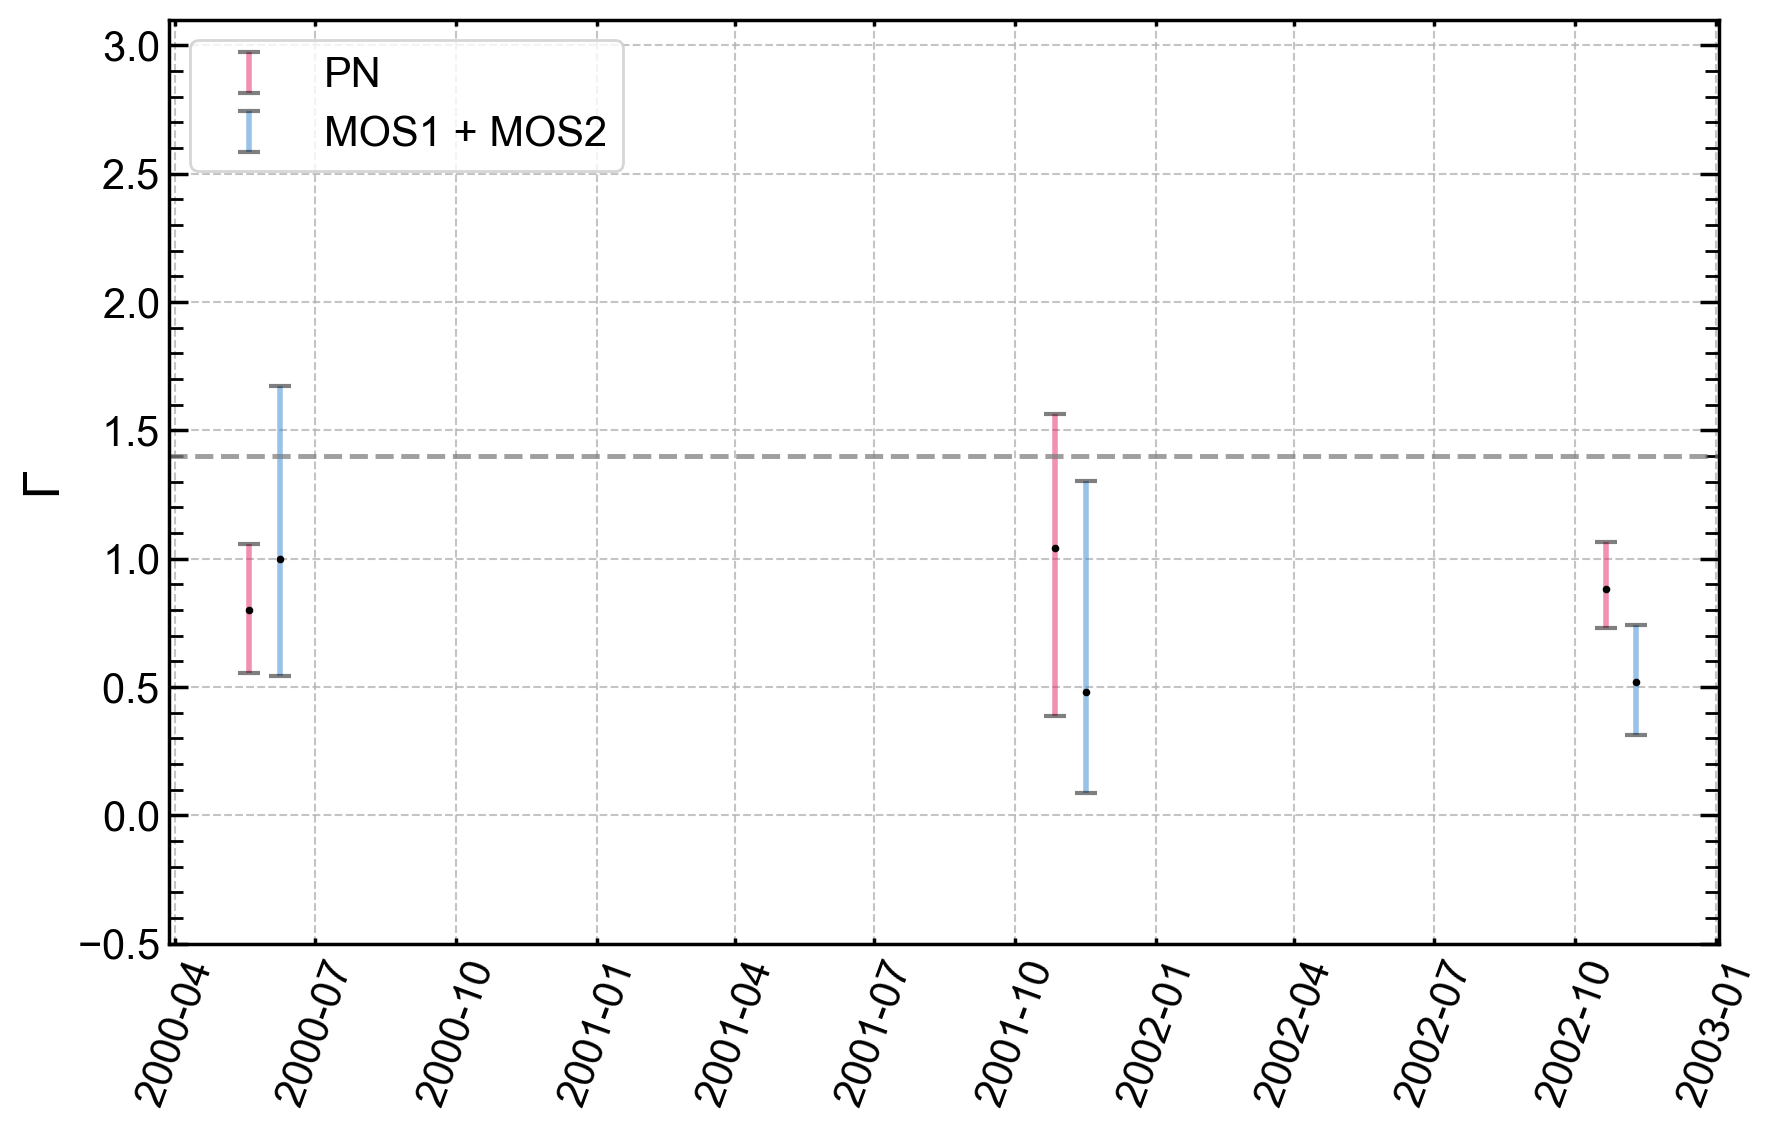

In [5]:
src_5359_df = pd.read_csv('../data/source_201237001010017_5359_clustered_PN_results.csv')

ax = plot_date_gamma(src_5359_df, "PN", color='C1')

src_5359_df = pd.read_csv('../data/source_201237001010017_5359_clustered_MOS_results.csv')

ax = plot_date_gamma(src_5359_df, 'MOS1 + MOS2', color='C0', ax=ax, pad=True)

# ax.set_title("srcid 5359 | PN and MOS1 + MOS2 clustered; ph*zph*zpo", loc='left')

<Axes: ylabel='Г'>

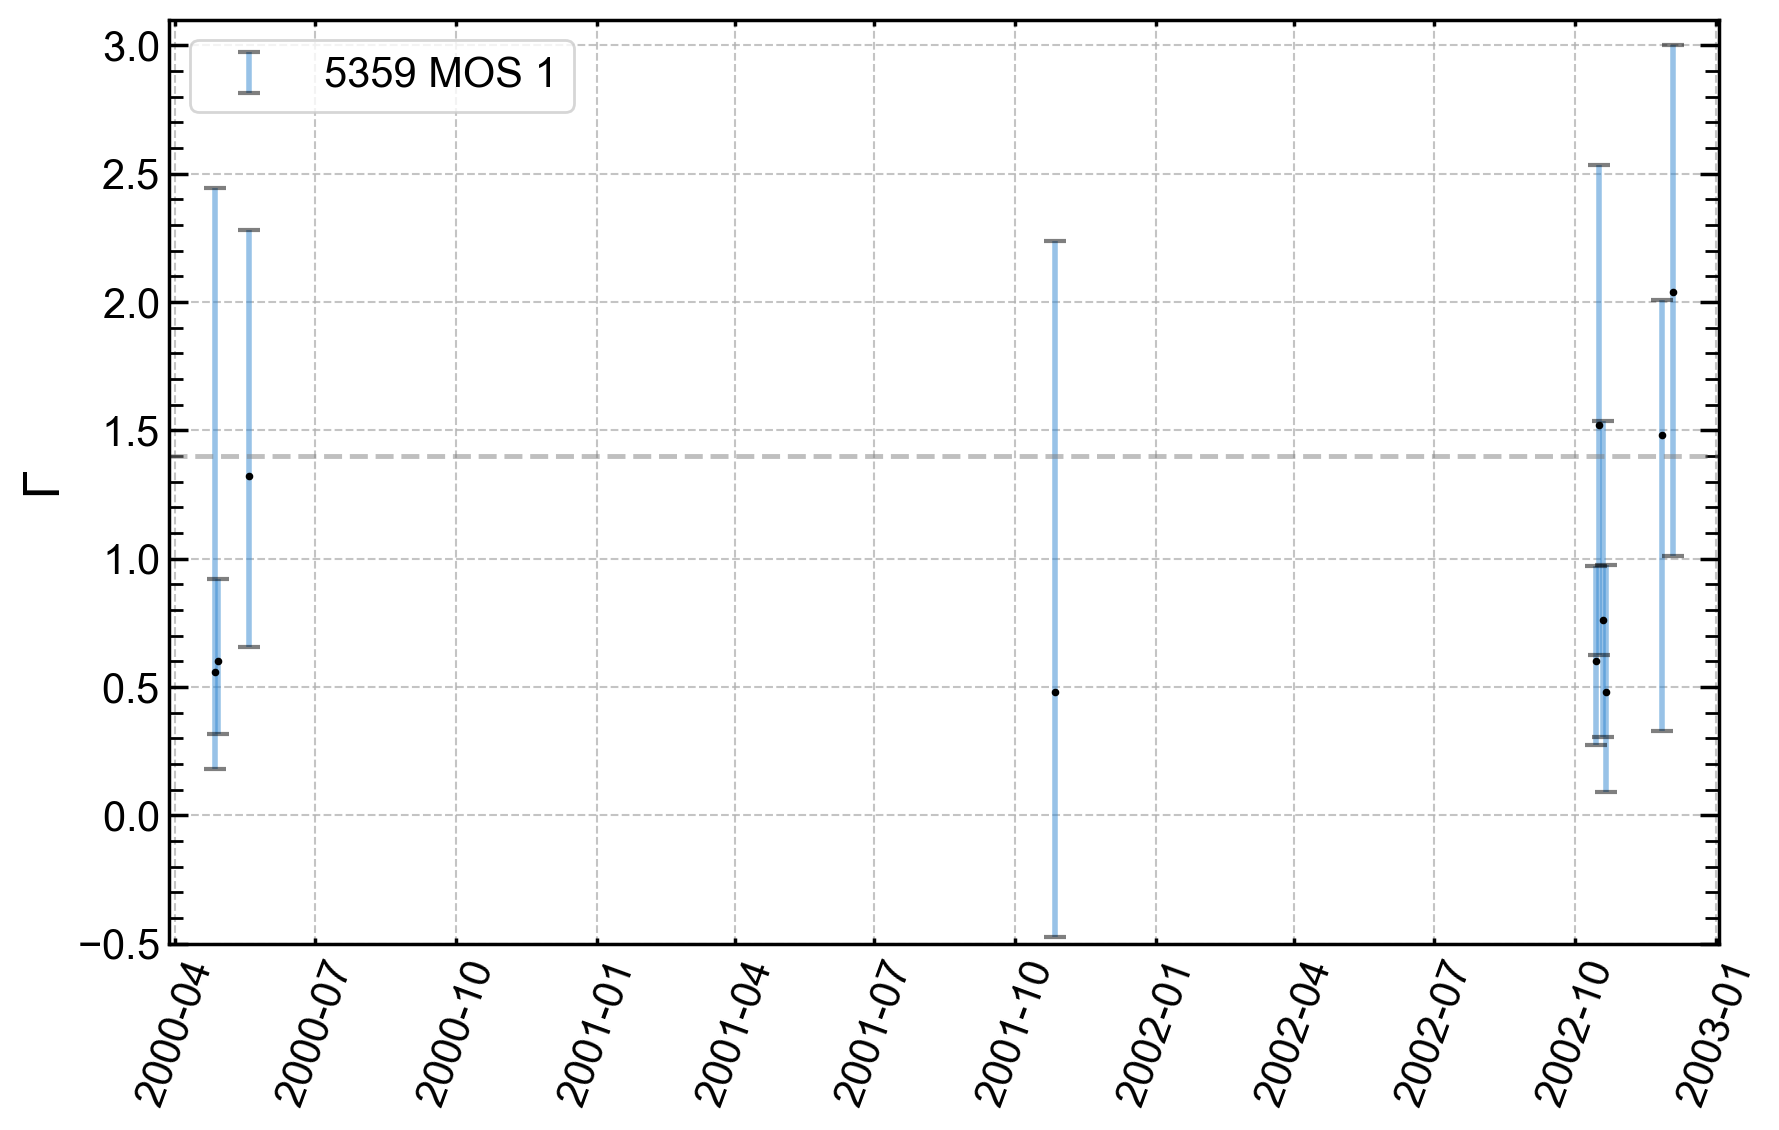

In [9]:
src_5359_M1_df = pd.read_csv('../data/source_201237001010017_5359_individual_M1_results.csv')

plot_date_gamma(src_5359_M1_df, "5359 MOS 1", color='C0')

<Axes: ylabel='Г'>

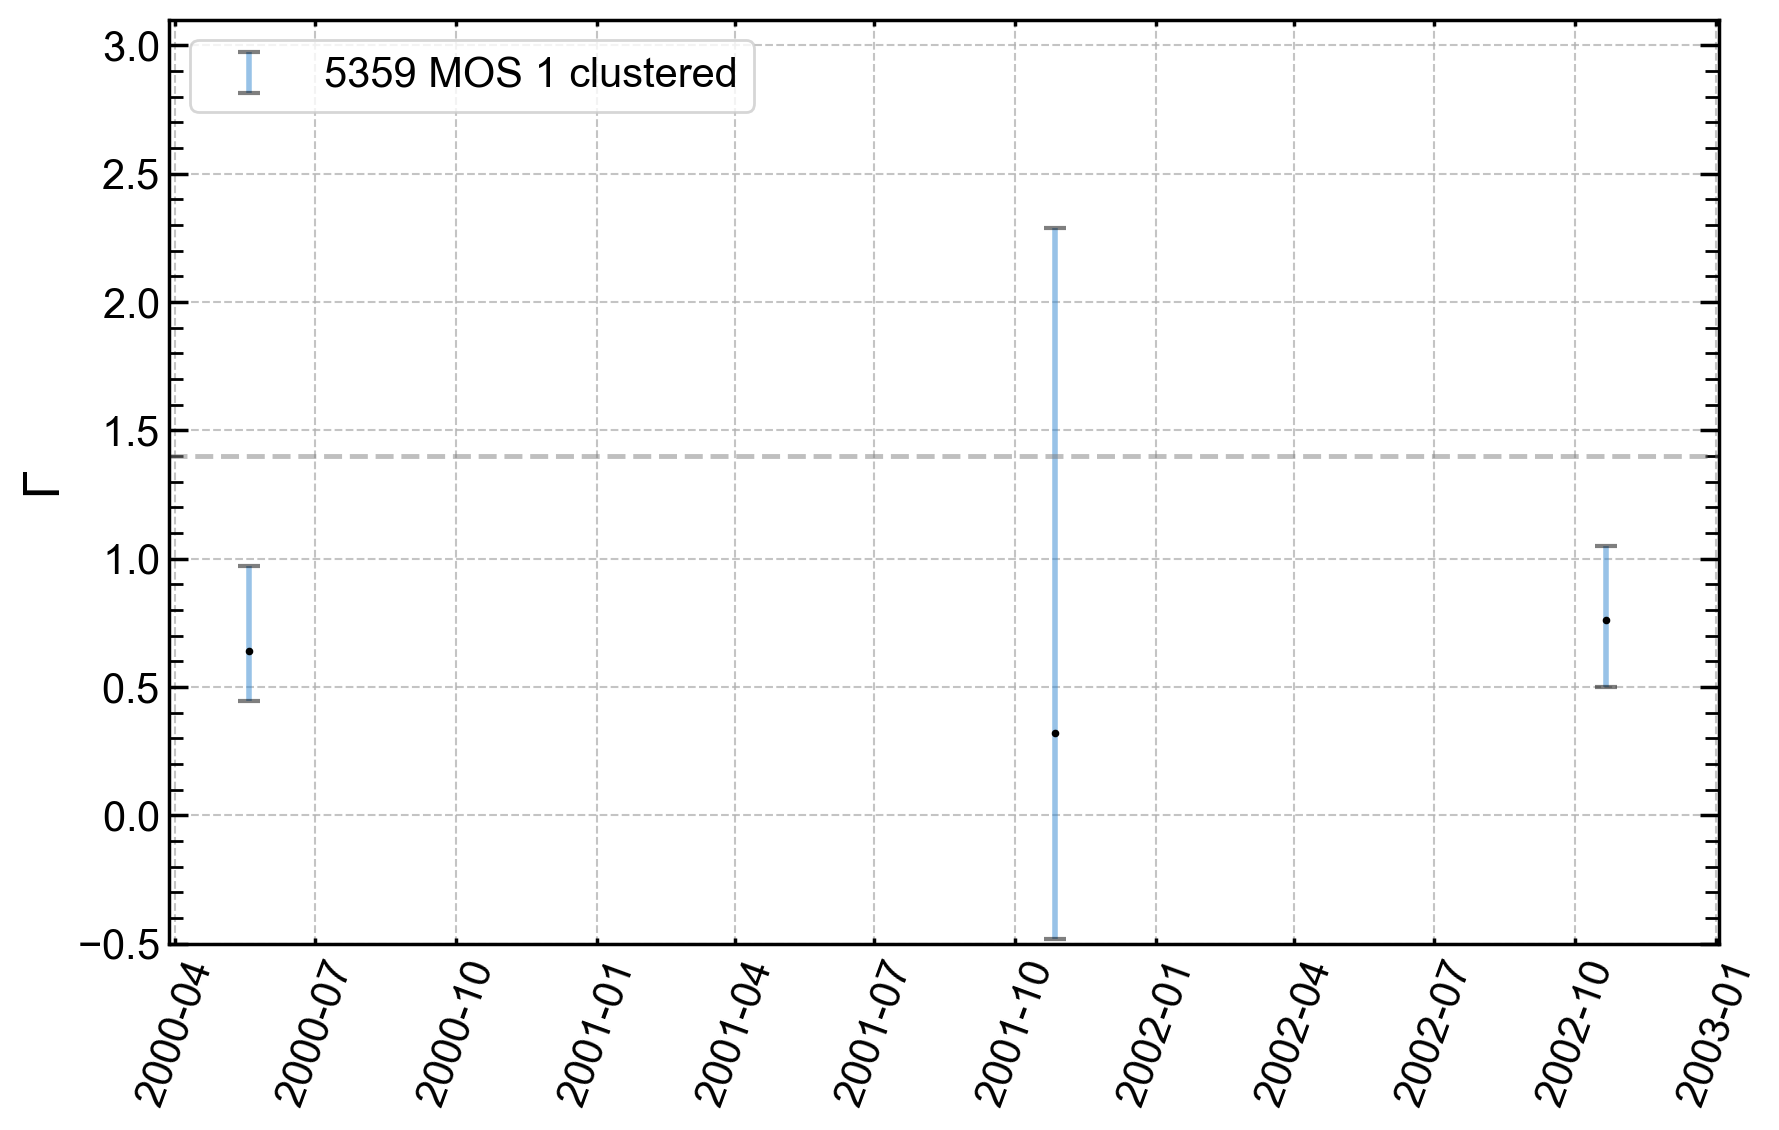

In [10]:
src_5359_M1_cluster_df = pd.read_csv('../data/source_201237001010017_5359_clustered_M1_results.csv')

plot_date_gamma(src_5359_M1_cluster_df, "5359 MOS 1 clustered", color='C0')

<Axes: ylabel='Г'>

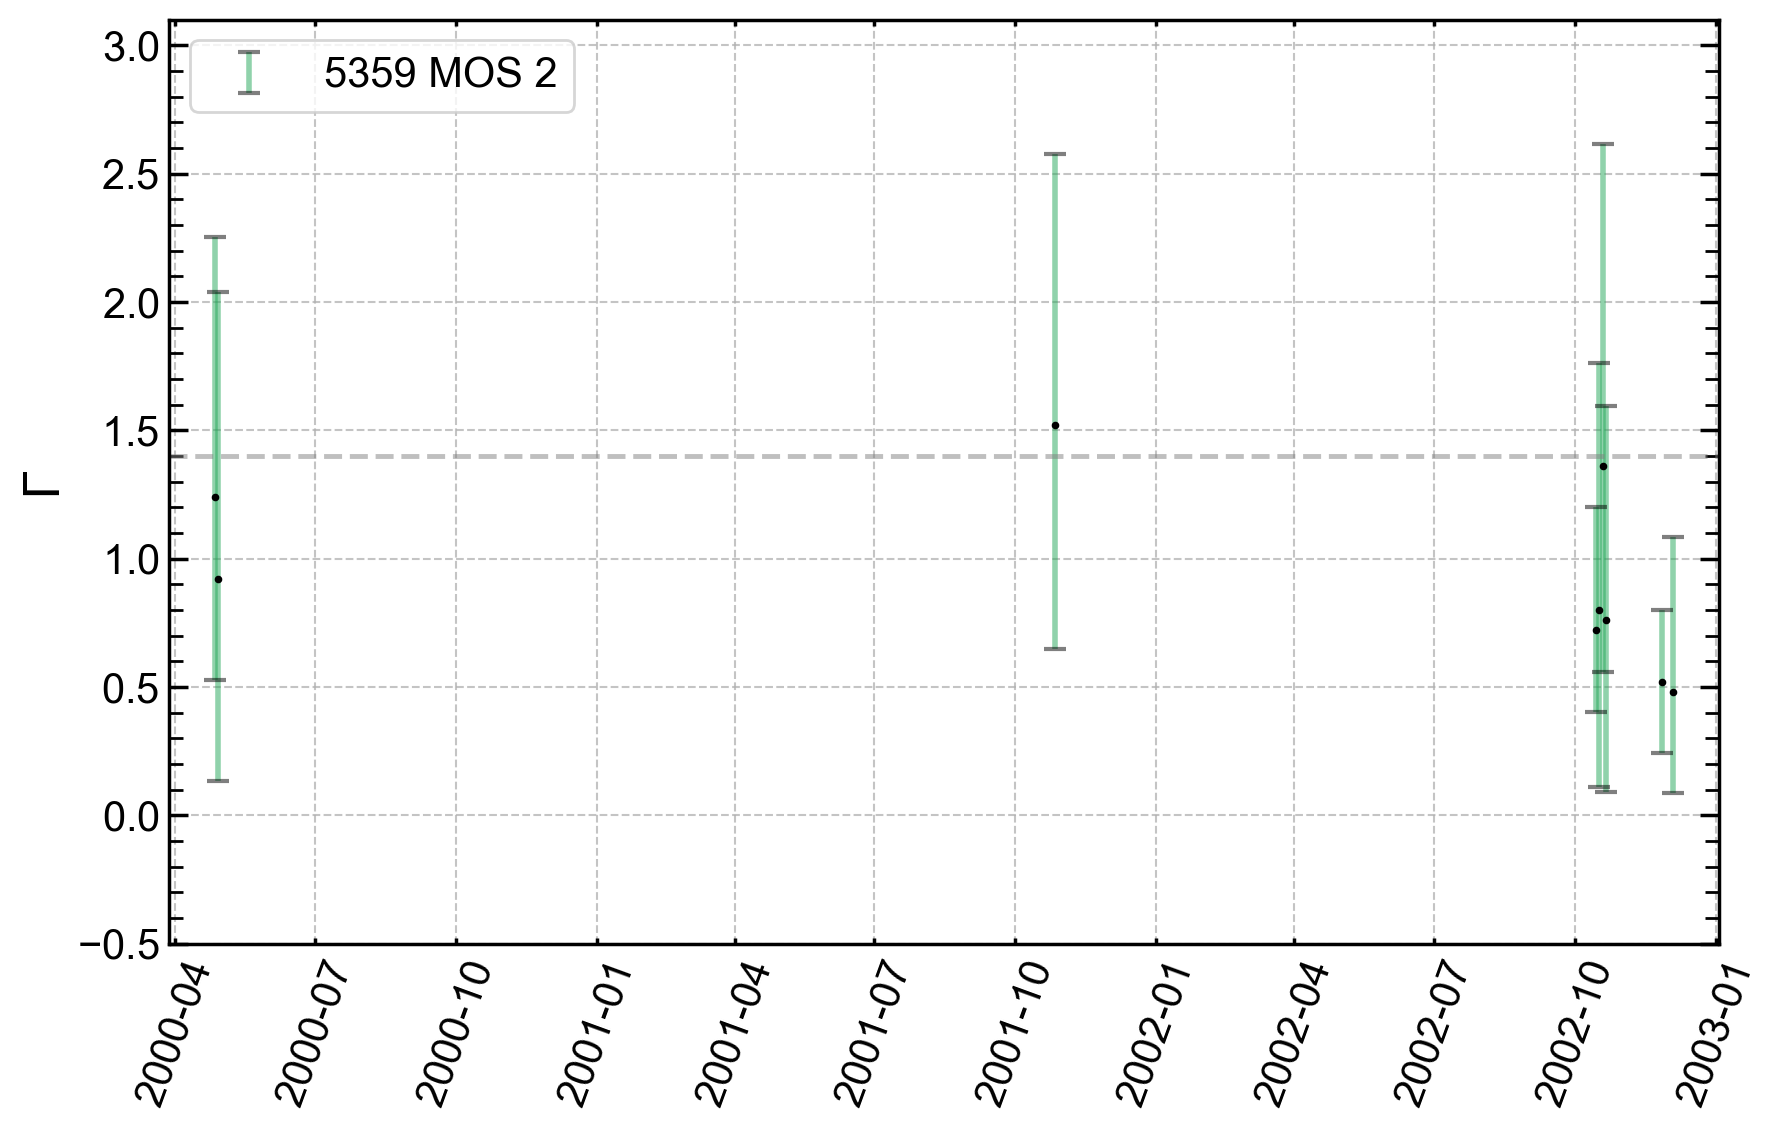

In [11]:
src_5359_M2_df = pd.read_csv('../data/source_201237001010017_5359_individual_M2_results.csv')

plot_date_gamma(src_5359_M2_df, "5359 MOS 2", color='C2')

<Axes: ylabel='Г'>

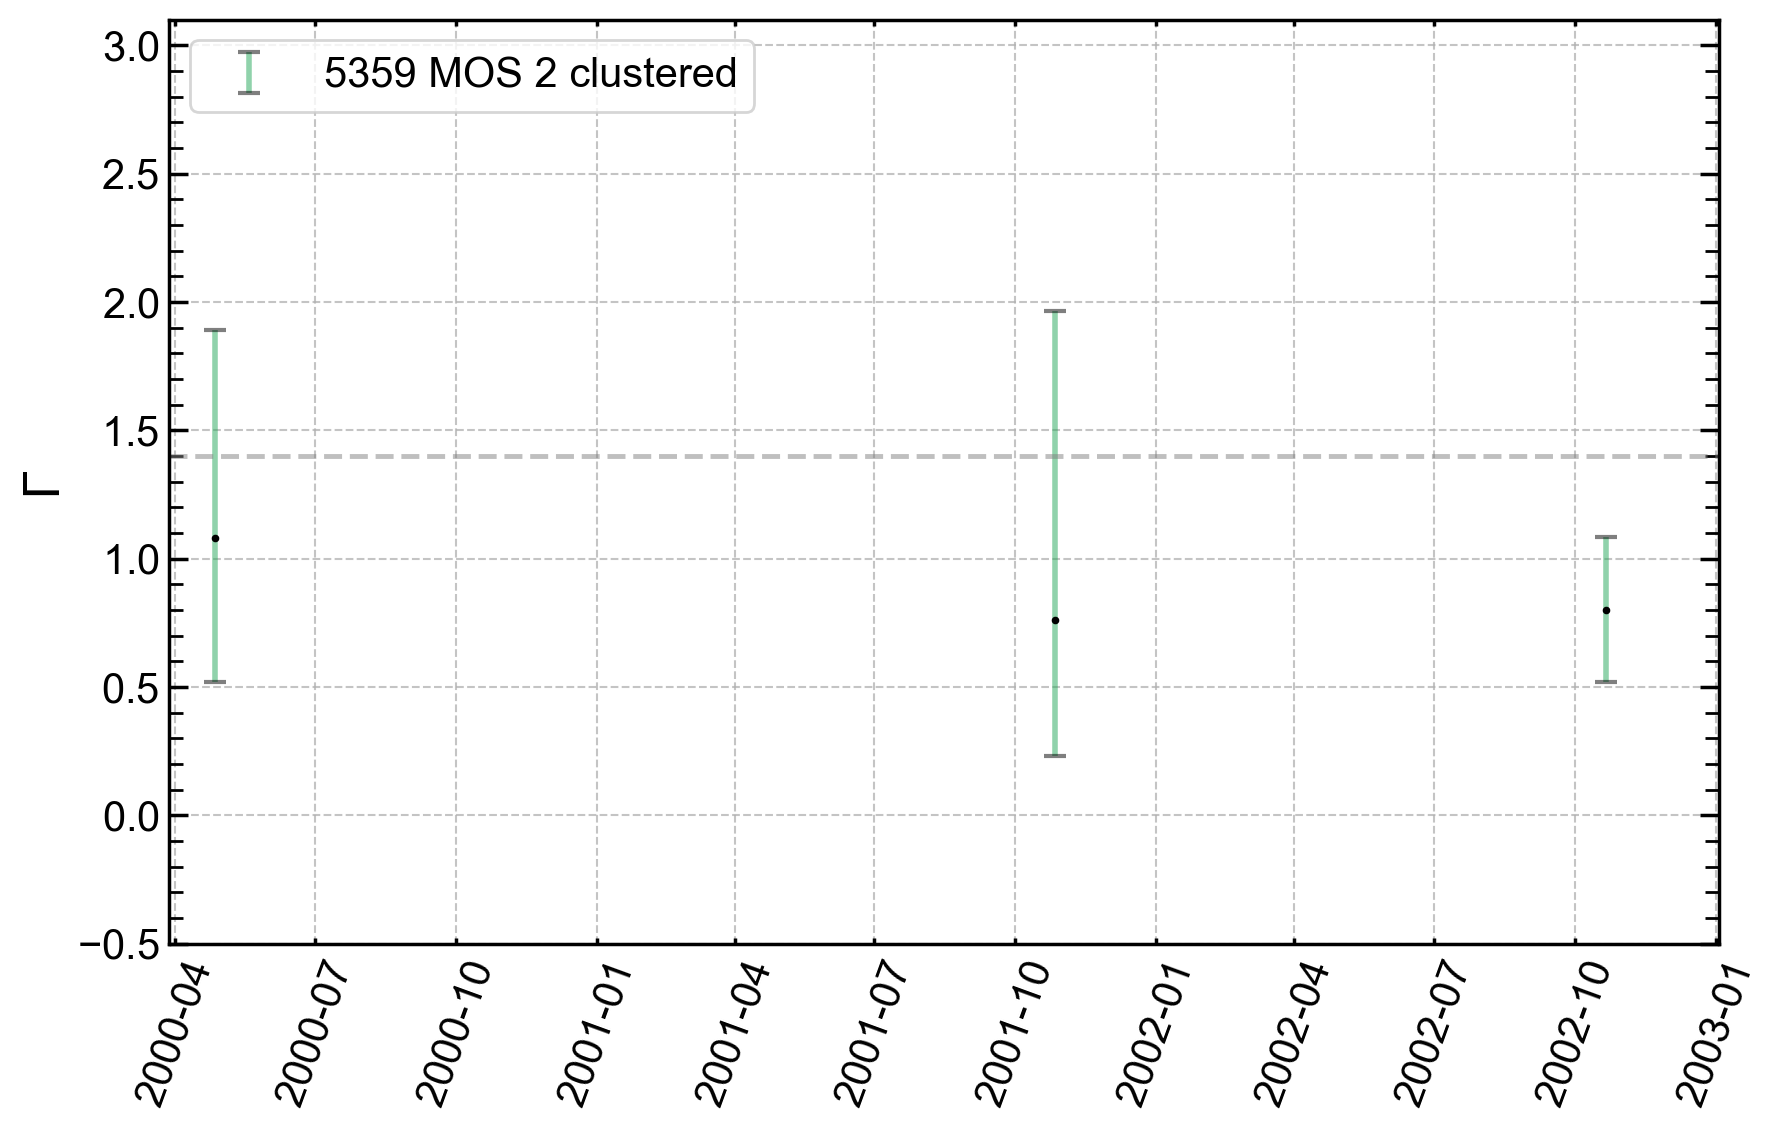

In [12]:
src_5359_M2_cluster_df = pd.read_csv('../data/source_201237001010017_5359_clustered_M2_results.csv')

plot_date_gamma(src_5359_M2_cluster_df, "5359 MOS 2 clustered", color='C2')

<Axes: ylabel='Г'>

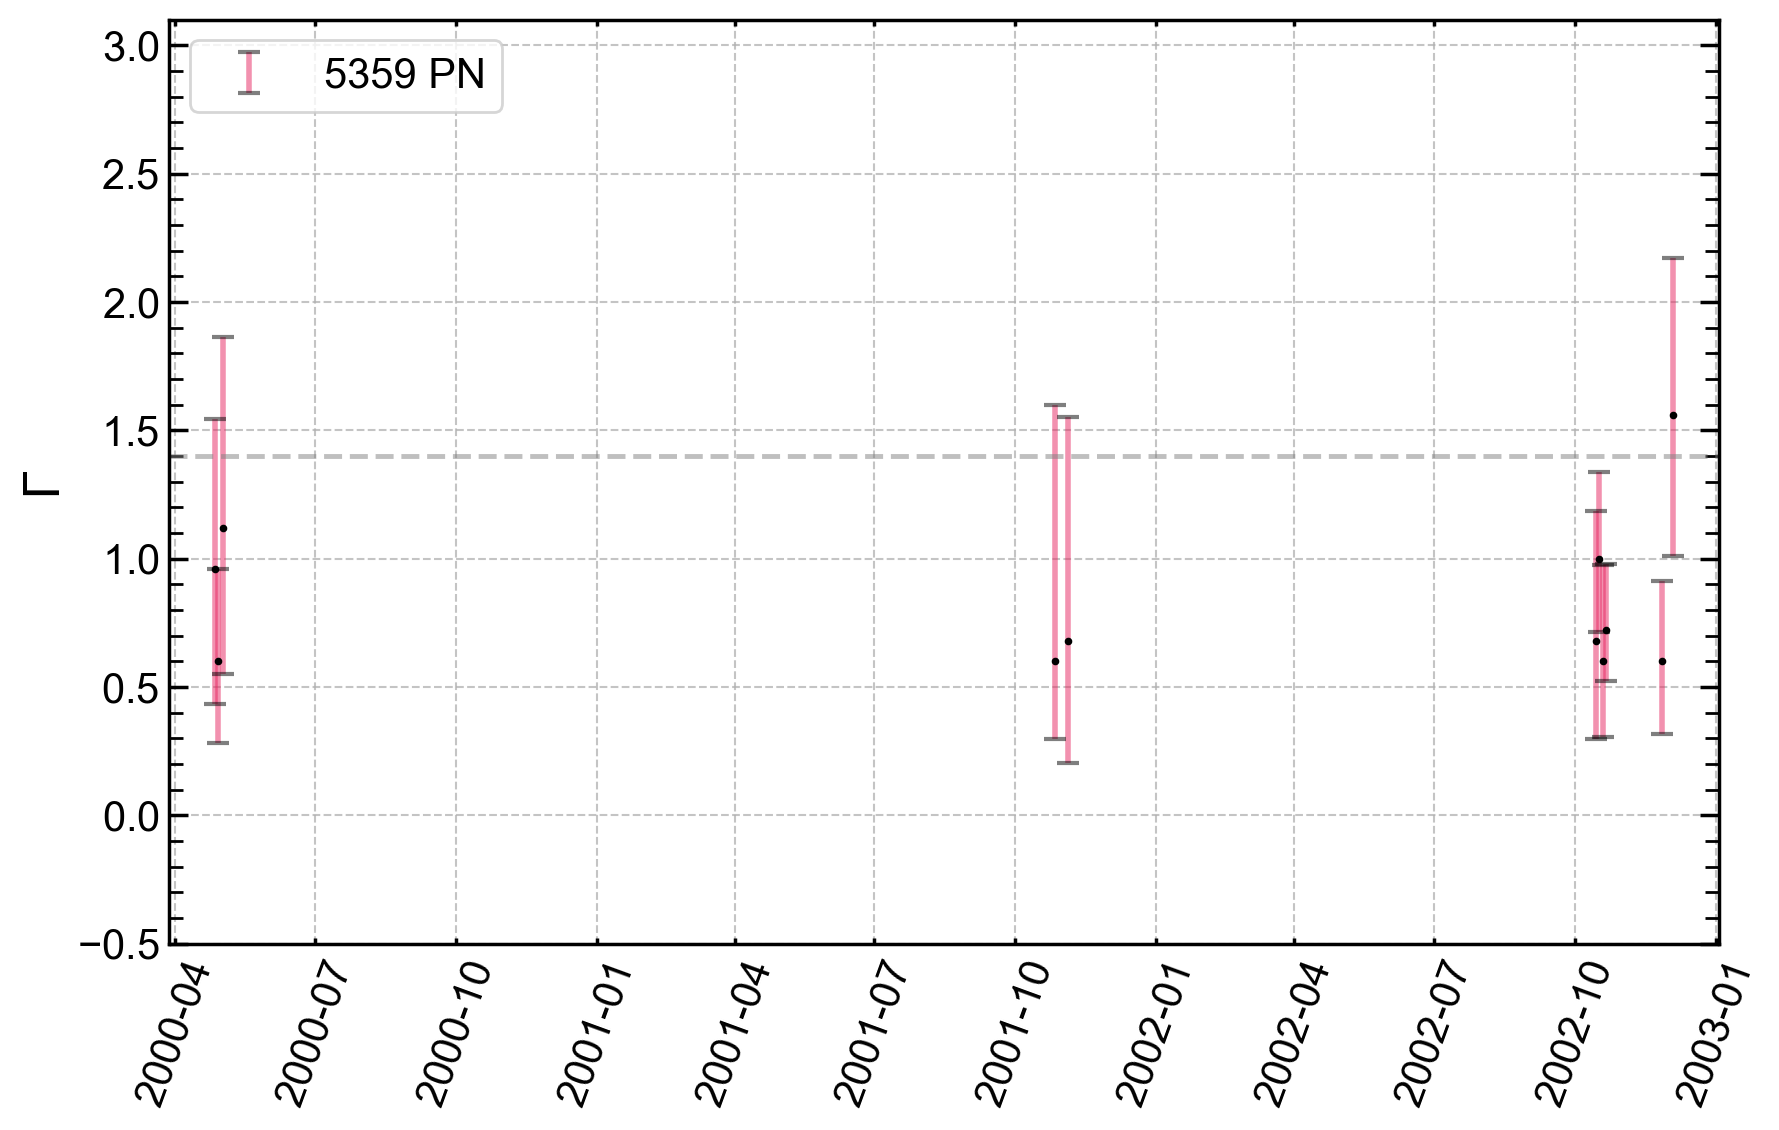

In [13]:
src_5359_df = pd.read_csv('../data/source_201237001010017_5359_results.csv')

plot_date_gamma(src_5359_df, "5359 PN", color='C1')

<Axes: ylabel='Г'>

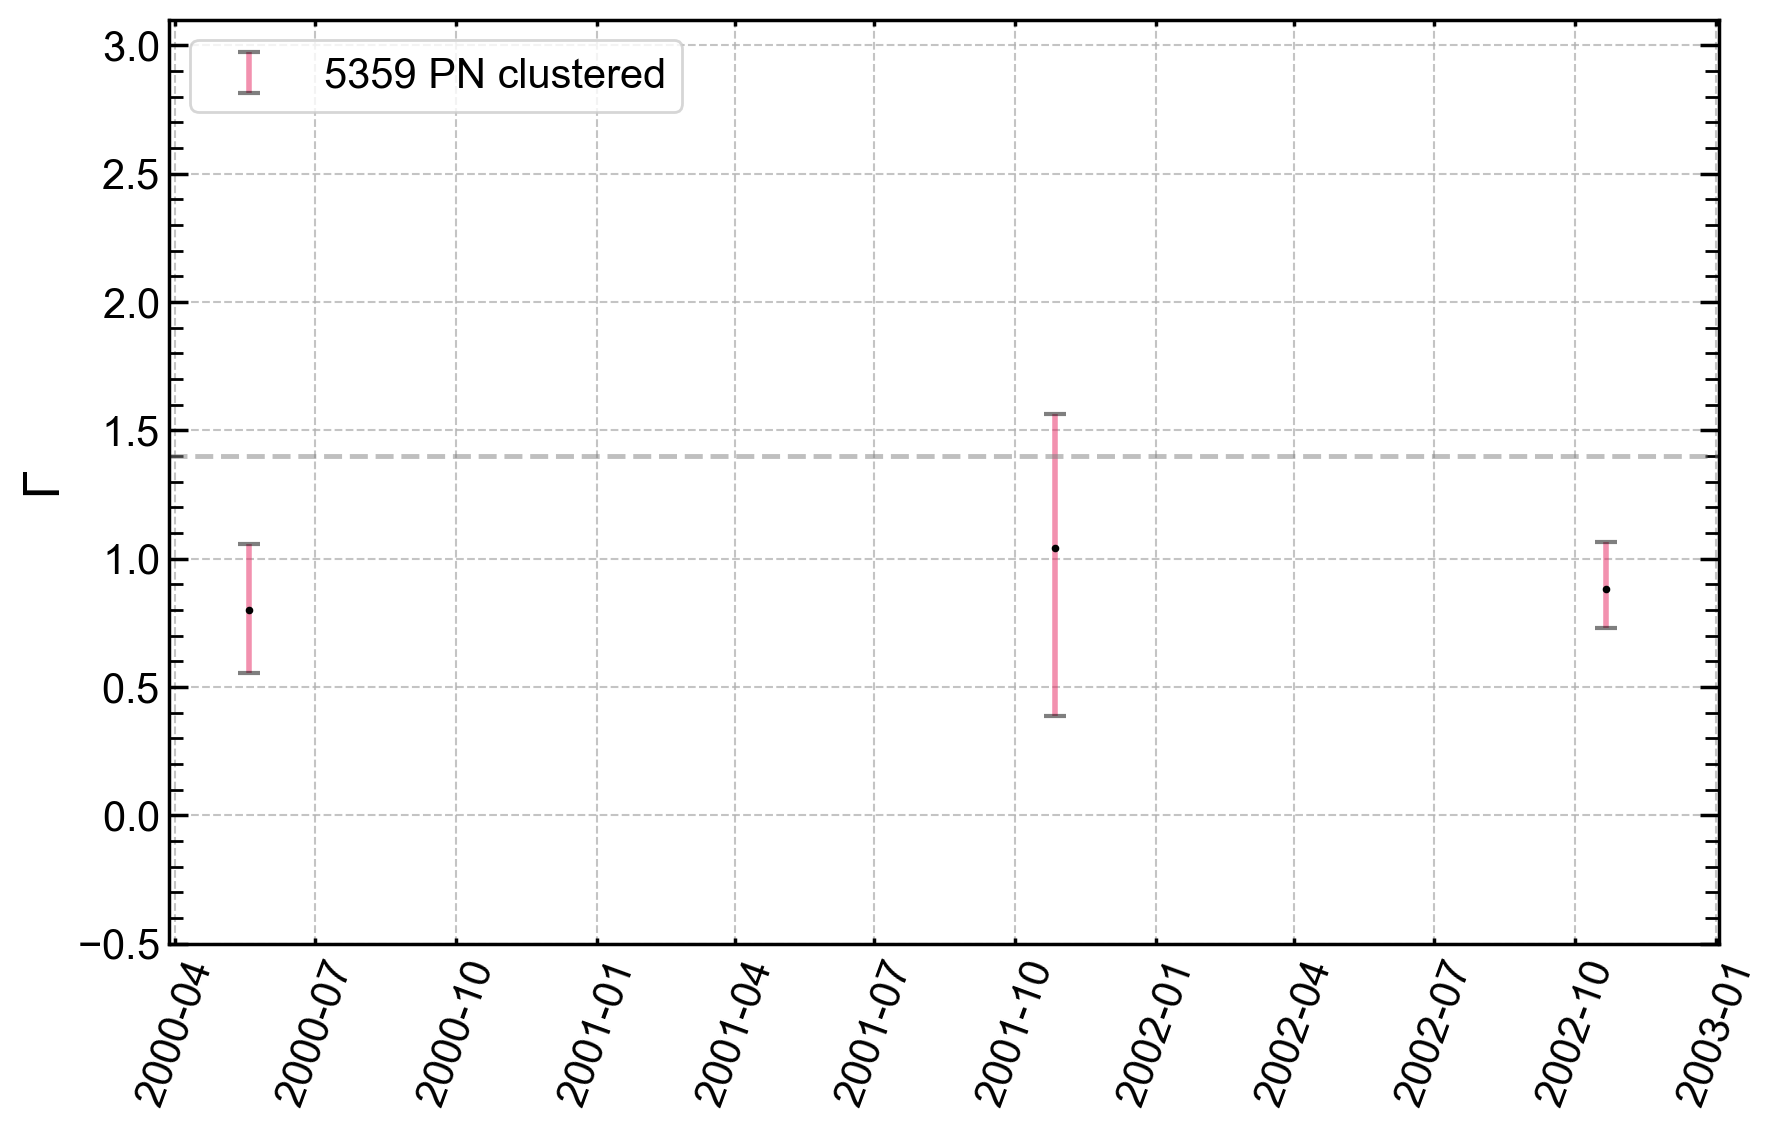

In [14]:
src_5359_df = pd.read_csv('../data/source_201237001010017_5359_clustered_PN_results.csv')

plot_date_gamma(src_5359_df, "5359 PN clustered", color='C1')

In [15]:
# dfs = [src_1430_df, src_5359_df, src_7170_df]
# srcids = "1430", "5359", "7170"

# for df, title in zip(dfs, srcids):
#     plot_date_gamma(df, title)

***

**Downloading details**

In [16]:
# df = pd.read_csv('../data/spectra_to_download/deep_xmm_lh_full_ontime.csv')

# slim_ontime_df = df.query('user_srcid == 5359').sort_values('pn_ontime', ascending=False)[target_columns].reset_index(drop=True)

# download_log_df = pd.read_csv('../data/downloaded_spectra/download_meta.csv')

# slim_status_df = download_log_df[['src_num', 'obs_id', 'status']]

# slim_ontime_df.merge(slim_status_df, on=['src_num', 'obs_id'])